In [1]:
import pandas as pd

df1 = pd.read_csv('dataset1.csv')
df2 = pd.read_csv('dataset2.csv')
df3 = pd.read_csv('dataset3.csv')


In [2]:
merged_df = df1.merge(df2, on='ID').merge(df3, on='ID')


<h2><b>Data Inspection</b></h2>

In [3]:
merged_df.head(5)

,ID,gender,minority,deprived,C_we,C_wk,G_we,G_wk,S_we,S_wk,...,Engs,Dealpr,Thcklr,Goodme,Clsep,Conf,Mkmind,Loved,Intthg,Cheer
0,1087192,0,0,0,2.0,0.5,0.5,0.5,1.0,0.5,...,4,4,4,4,5,4,4,5,4,4
1,1087195,0,0,0,2.0,1.0,0.0,0.0,3.0,1.0,...,3,4,5,3,5,4,4,5,4,4
2,1087205,0,0,0,1.0,0.5,0.0,0.0,0.5,0.5,...,3,3,3,3,4,3,3,3,4,4
3,1087214,0,0,0,2.0,1.0,0.5,0.0,2.0,1.0,...,4,4,4,4,3,5,4,5,4,4
4,1087222,0,0,0,1.0,3.0,0.0,0.0,2.0,1.0,...,2,3,3,4,4,3,5,5,5,5


In [4]:
merged_df.tail()

,ID,gender,minority,deprived,C_we,C_wk,G_we,G_wk,S_we,S_wk,...,Engs,Dealpr,Thcklr,Goodme,Clsep,Conf,Mkmind,Loved,Intthg,Cheer
98273,1091072,1,0,1,7.0,7.0,7.0,7.0,7.0,7.0,...,5,3,2,1,1,2,3,5,5,2
98274,1091077,1,0,1,7.0,5.0,7.0,5.0,7.0,6.0,...,4,4,2,2,4,2,3,2,2,2
98275,1091104,1,0,1,5.0,5.0,5.0,5.0,5.0,5.0,...,5,4,4,4,4,4,4,4,4,4
98276,1091112,1,0,1,6.0,6.0,5.0,3.0,7.0,7.0,...,4,3,4,4,4,3,4,3,2,3
98277,1091115,1,0,1,6.0,6.0,5.0,3.0,7.0,5.0,...,2,4,5,2,5,3,5,4,3,2


In [5]:
rows,cols=merged_df.shape
print("Number of Records =",rows)
print("Number of Features =",cols)

Number of Records = 98278
Number of Features = 26


In [6]:
print(merged_df.dtypes)

ID            int64
gender        int64
minority      int64
deprived      int64
C_we        float64
C_wk        float64
G_we        float64
G_wk        float64
S_we        float64
S_wk        float64
T_we        float64
T_wk        float64
Optm          int64
Usef          int64
Relx          int64
Intp          int64
Engs          int64
Dealpr        int64
Thcklr        int64
Goodme        int64
Clsep         int64
Conf          int64
Mkmind        int64
Loved         int64
Intthg        int64
Cheer         int64
dtype: object


In [7]:
continuous_features = ['C_we', 'C_wk', 'G_we', 'G_wk', 'S_we', 'S_wk', 'T_we', 'T_wk']
categorical_features = ['gender','minority','deprived']
target_variables = ['Optm', 'Usef', 'Relx', 'Intp', 'Engs', 'Dealpr', 'Thcklr', 'Goodme', 
                    'Clsep', 'Conf', 'Mkmind', 'Loved', 'Intthg', 'Cheer']

<h2><b>Summary Statistics</b></h2>

In [8]:
merged_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,98278.0,1.059895e+06,34793.098252,1000002.0,1029695.25,1059692.5,1090142.75,1120115.0
gender,98278.0,4.720589e-01,0.499221,0.0,0.00,0.0,1.00,1.0
minority,98278.0,2.265716e-01,0.418615,0.0,0.00,0.0,0.00,1.0
deprived,98278.0,4.240217e-01,0.494196,0.0,0.00,0.0,1.00,1.0
C_we,98278.0,2.198483e+00,2.069802,0.0,0.50,2.0,3.00,7.0
C_wk,98278.0,1.768092e+00,1.722842,0.0,0.50,1.0,3.00,7.0
G_we,98278.0,1.726332e+00,2.159675,0.0,0.00,0.5,3.00,7.0
G_wk,98278.0,9.978276e-01,1.540496,0.0,0.00,0.0,2.00,7.0
S_we,98278.0,3.504085e+00,2.490748,0.0,1.00,3.0,6.00,7.0
S_wk,98278.0,2.889604e+00,2.326138,0.0,1.00,2.0,5.00,7.0


<h2><b>Handling Missing Data</b></h2>

In [9]:
merged_df.isnull().sum()

ID          0
gender      0
minority    0
deprived    0
C_we        0
C_wk        0
G_we        0
G_wk        0
S_we        0
S_wk        0
T_we        0
T_wk        0
Optm        0
Usef        0
Relx        0
Intp        0
Engs        0
Dealpr      0
Thcklr      0
Goodme      0
Clsep       0
Conf        0
Mkmind      0
Loved       0
Intthg      0
Cheer       0
dtype: int64

<h2><b>Correlation Analysis</b></h2>

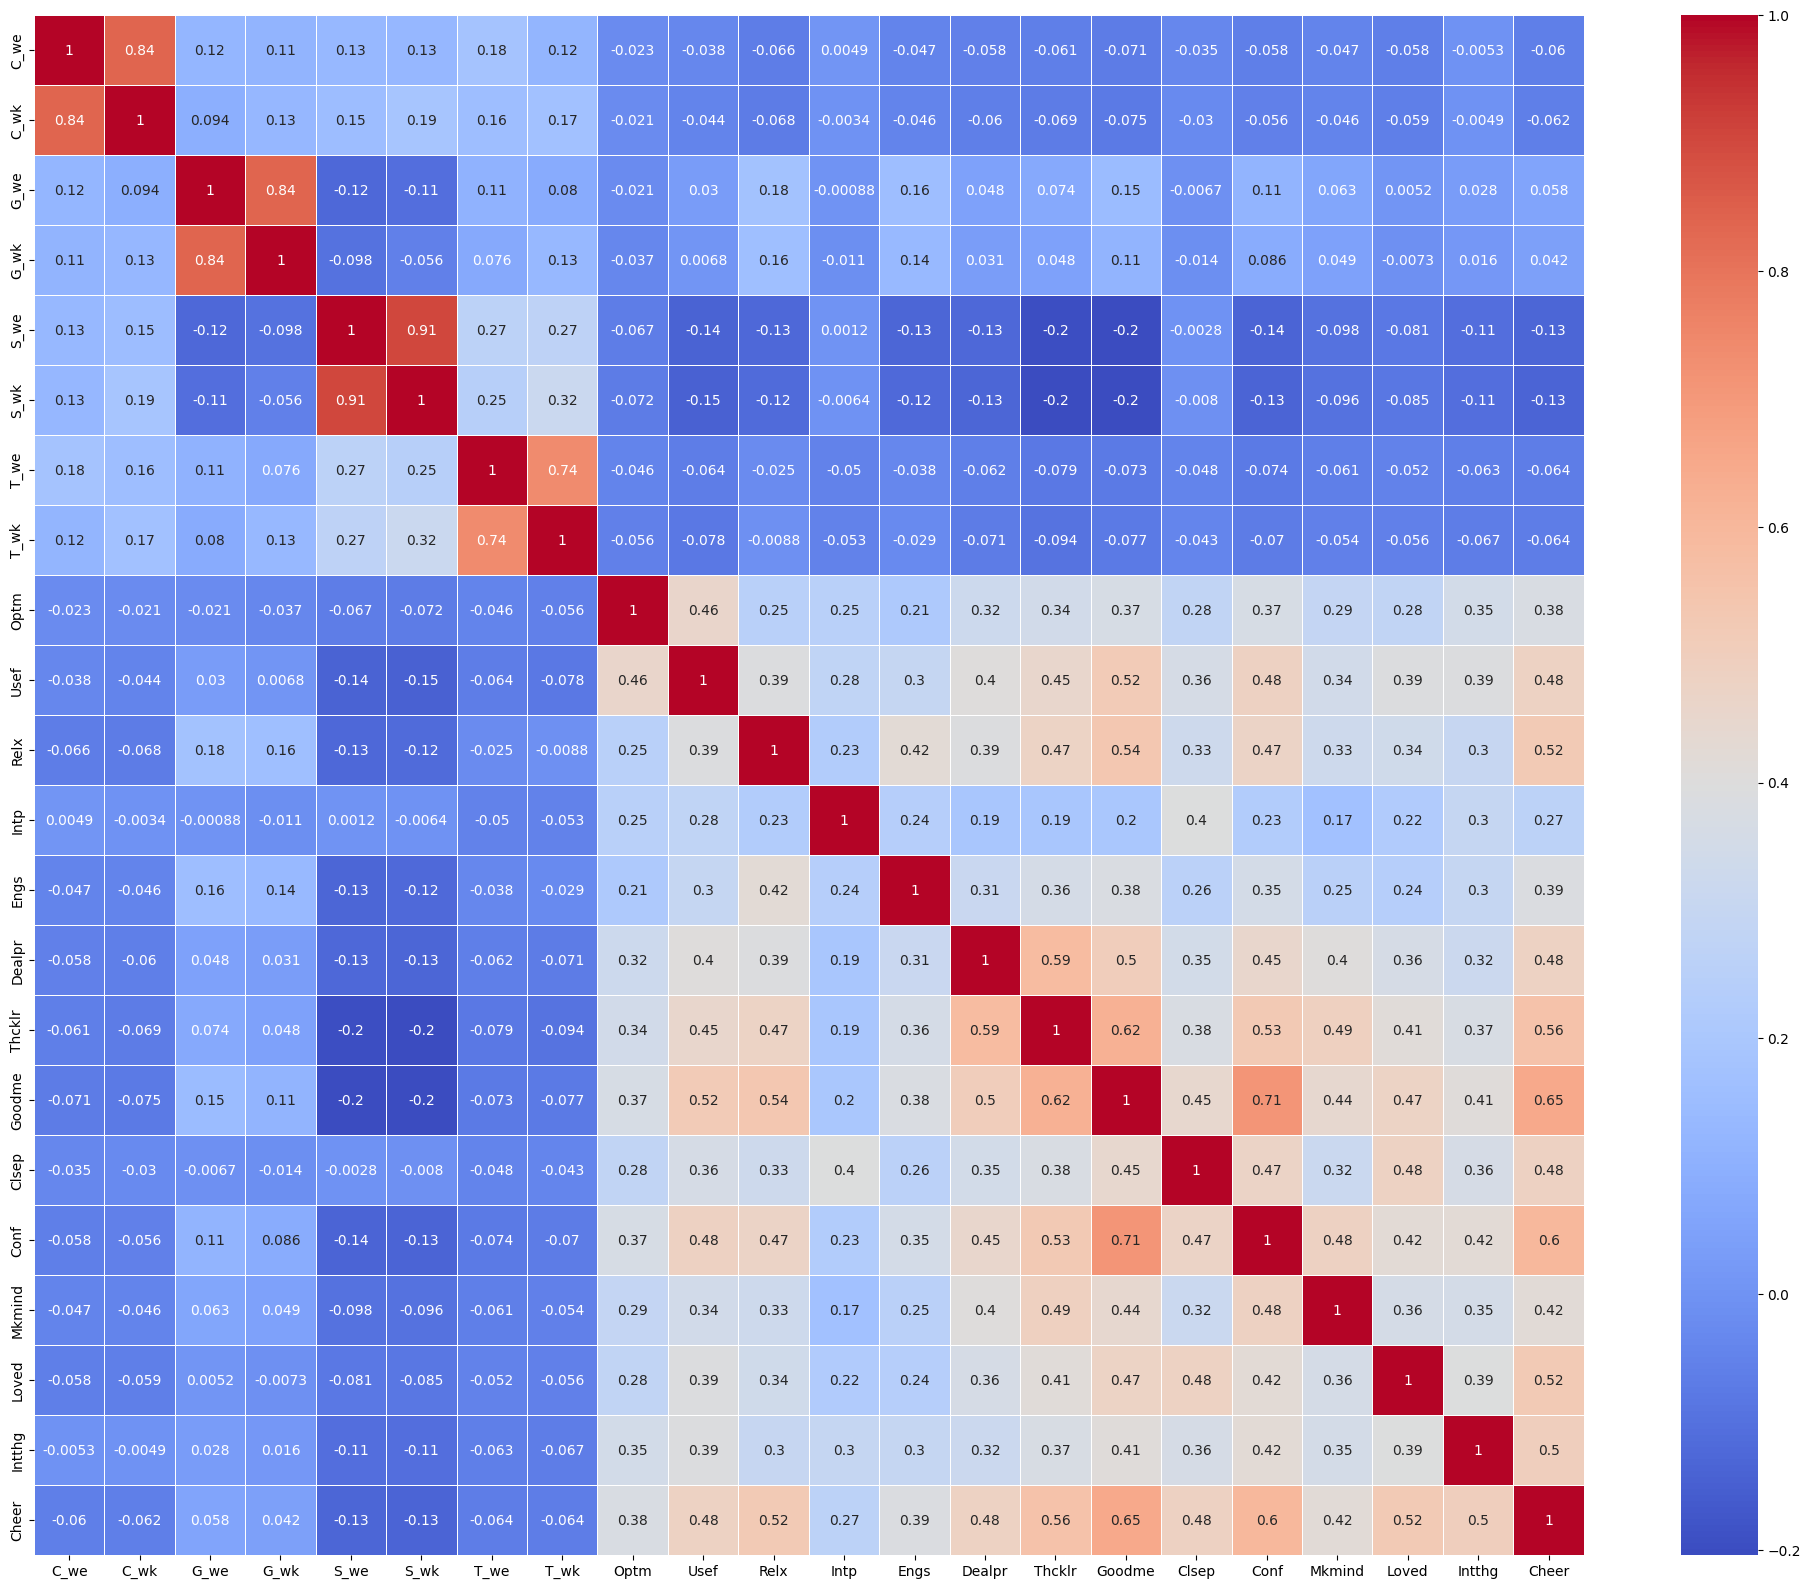

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(25, 20))
sns.heatmap(merged_df[continuous_features+target_variables].corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.show()


<h3><b>Handling Multicollinearity</b></h3>

In [11]:
merged_df['C_wk'] = (merged_df['C_wk'] * 7 + merged_df['C_we']) / 8
merged_df['G_wk'] = (merged_df['G_wk'] * 7 + merged_df['G_we']) / 8
merged_df['S_wk'] = (merged_df['S_wk'] * 7 + merged_df['S_we']) / 8
merged_df['T_wk'] = (merged_df['T_wk'] * 7 + merged_df['T_we']) / 8

merged_df.drop(columns=['C_we','G_we','S_we','T_we'], inplace=True)

: 

In [12]:
continuous_features = ['C_wk', 'G_wk', 'S_wk', 'T_wk']

<h2><b>Pairwise Relationships (Pairplot)</b></h2>

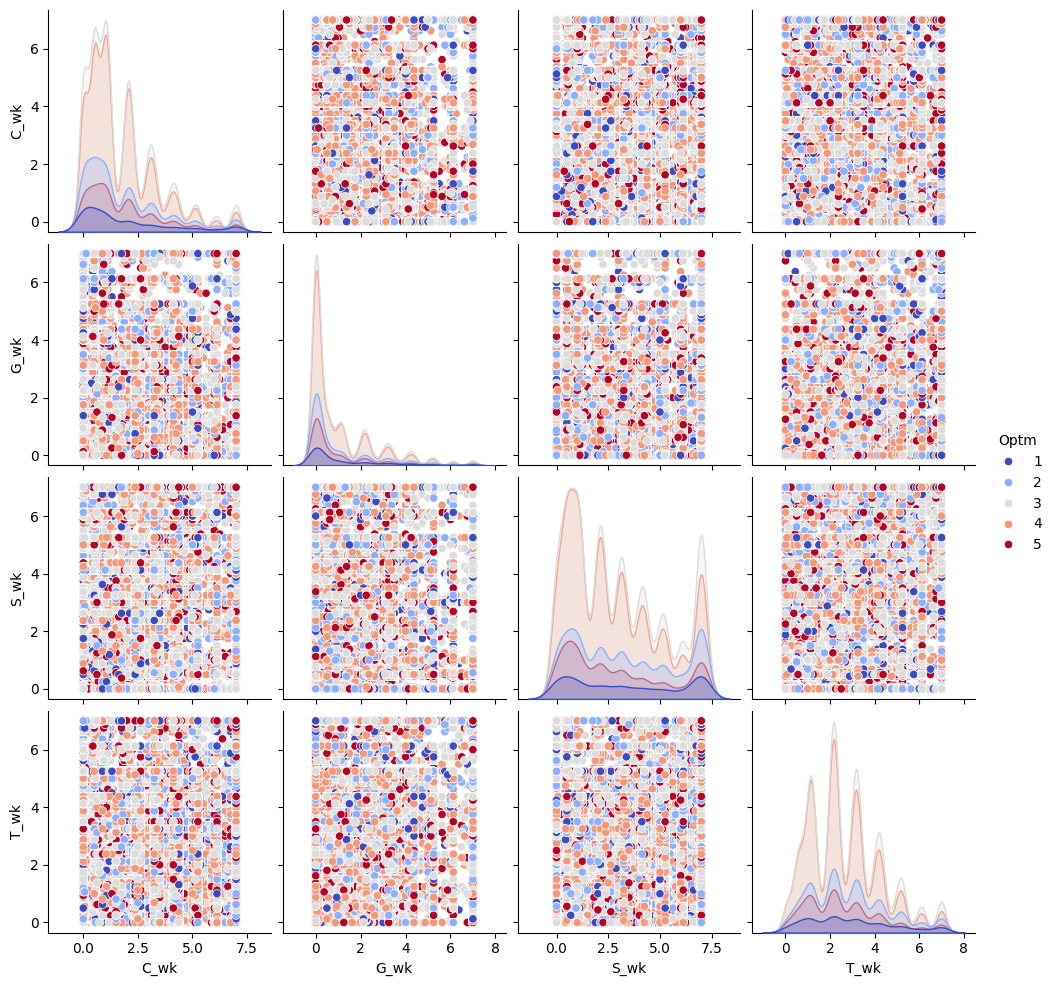

In [13]:
for target in target_variables:
    subset_df = merged_df[continuous_features + [target]]
    sns.pairplot(subset_df, hue=target, palette='coolwarm')
    plt.show()
    break


<h3><b>Scatter Plots</b></h3>

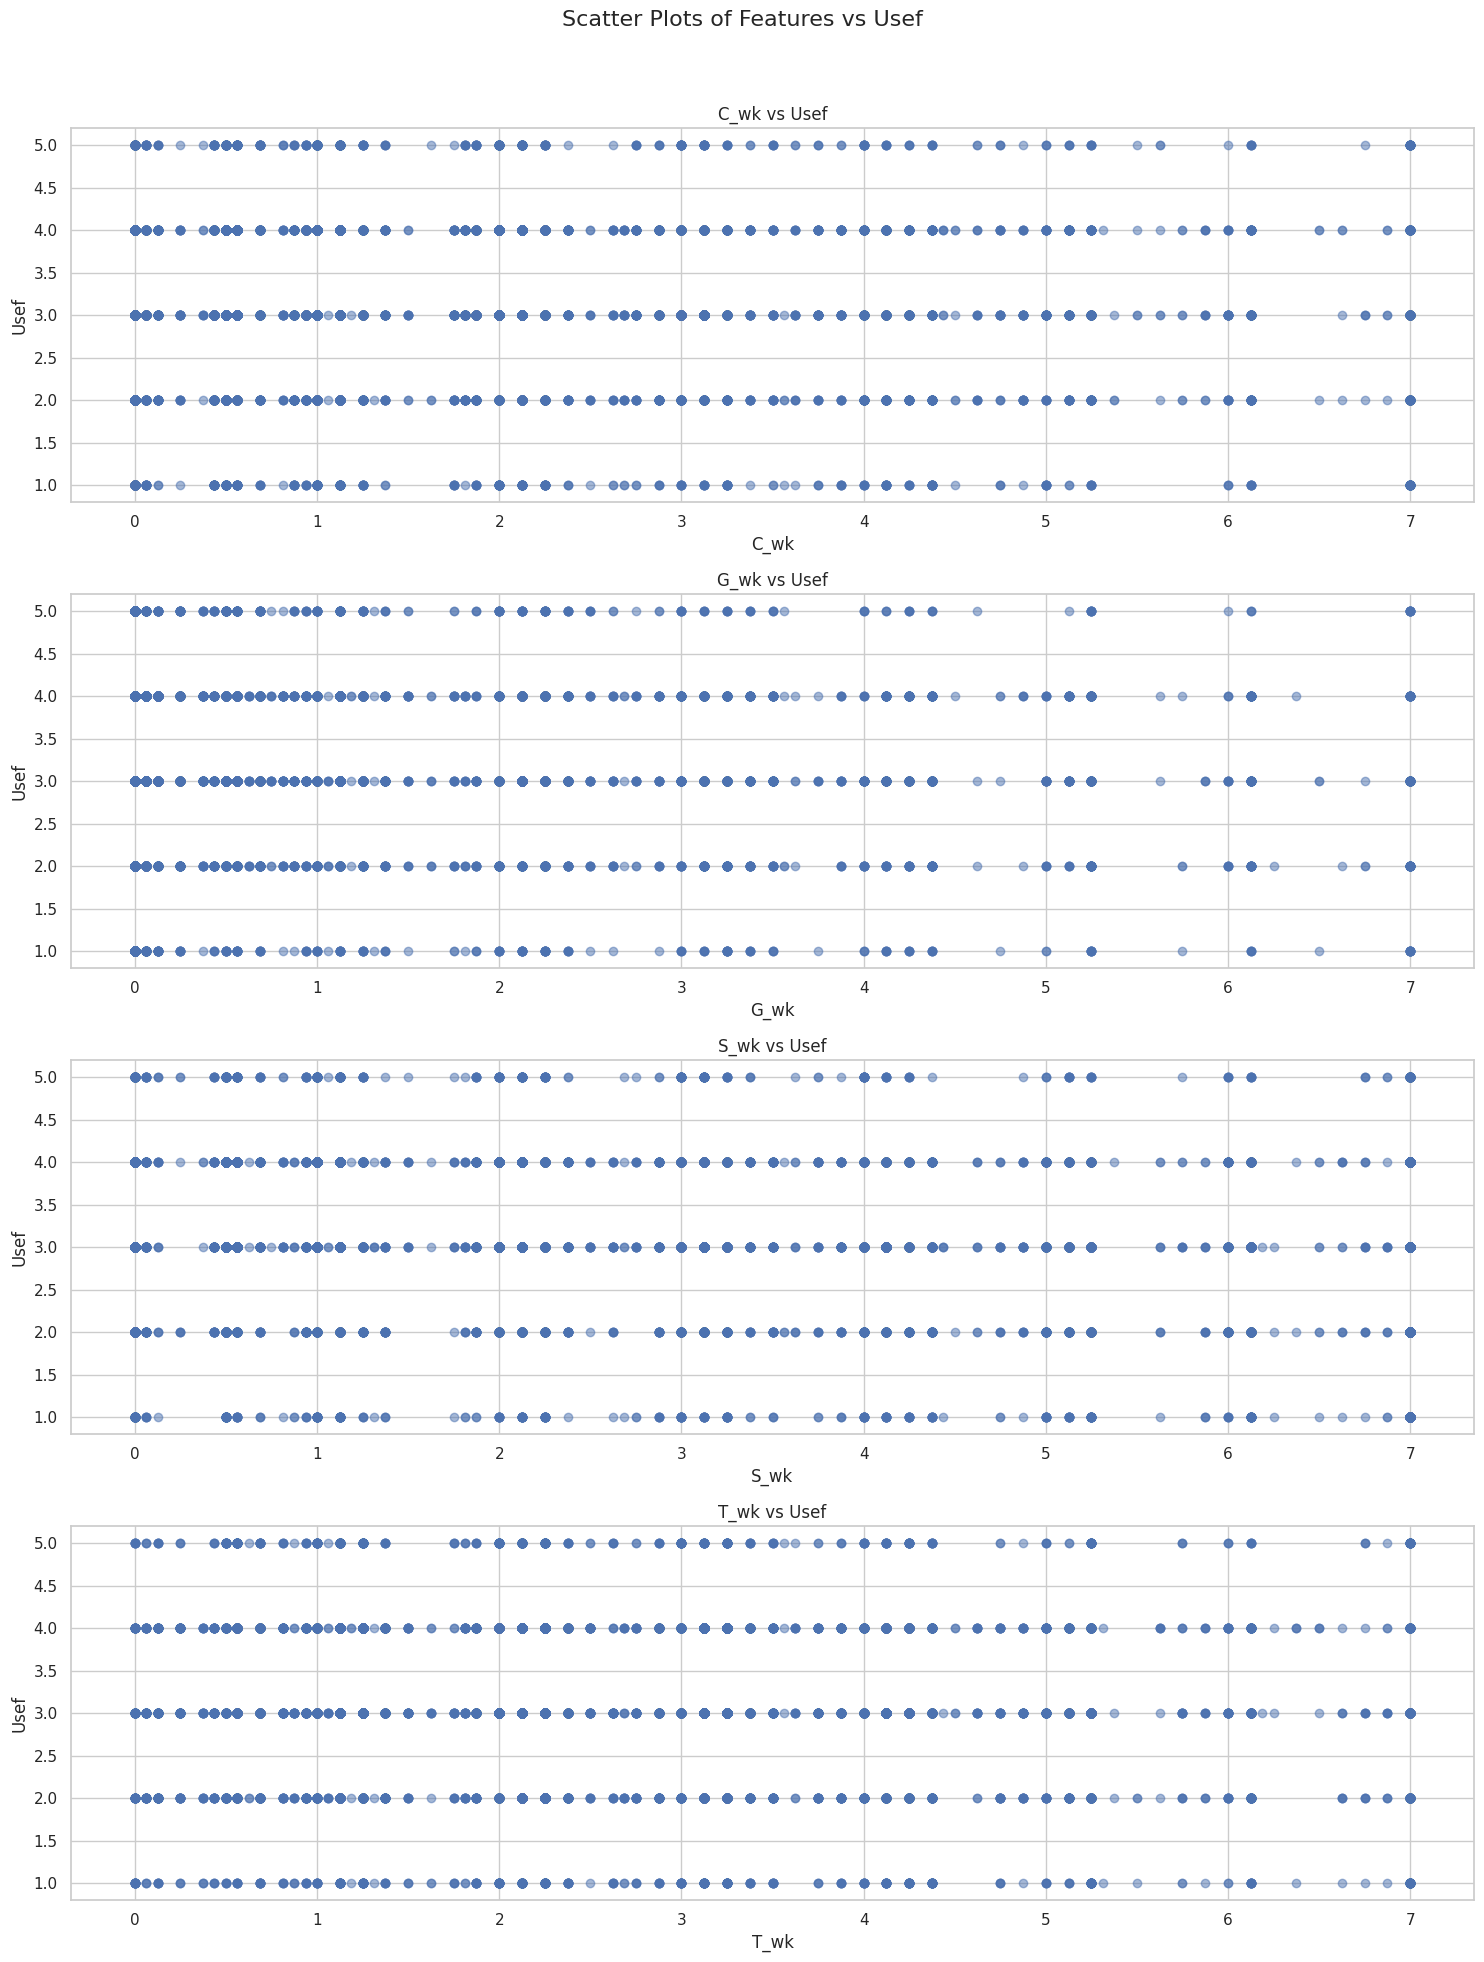

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set the style of seaborn
sns.set(style='whitegrid')

# Choose the target variable (e.g., the first one in the list)
target_variable = target_variables[1]

# Sample the data if necessary (e.g., using 10% of the data)
sampled_data = merged_df.sample(frac=0.1, random_state=1)  # Adjust the fraction as needed

# Create a grid of subplots for continuous features against the chosen target variable
num_features = len(continuous_features)
fig, axes = plt.subplots(num_features, 1, figsize=(15, 5 * num_features))
fig.suptitle(f'Scatter Plots of Features vs {target_variable}', fontsize=16)

# Loop through continuous features to create scatter plots against the target variable
for i in range(num_features):
    ax = axes[i]
    # Use scatter for faster plotting
    ax.scatter(sampled_data[continuous_features[i]], sampled_data[target_variable], alpha=0.5)
    ax.set_title(f'{continuous_features[i]} vs {target_variable}')
    ax.set_xlabel(continuous_features[i])
    ax.set_ylabel(target_variable)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust the layout to make room for the title
plt.show()


In [15]:
import numpy as np
import pandas as pd
from scipy import stats

# Lists to store results
significant_results = []
no_significant_results = []

# Iterate over all continuous features and target variables
for target in target_variables:
    # Get unique categories for the target variable
    unique_categories = merged_df[target].unique()
    
    # Iterate over all pairs of categories (for t-tests)
    for i in range(len(unique_categories)):
        for j in range(i + 1, len(unique_categories)):
            group1 = merged_df[merged_df[target] == unique_categories[i]][continuous_features]
            group2 = merged_df[merged_df[target] == unique_categories[j]][continuous_features]
            
            # Check if both groups have enough data to perform the t-test
            if len(group1) > 1 and len(group2) > 1:
                for feature in continuous_features:
                    # Perform t-test
                    t_stat, p_value = stats.ttest_ind(group1[feature], group2[feature], equal_var=False)  # Welch's t-test
                    
                    # Interpret the results
                    alpha = 0.05  # Significance level
    
                    if p_value < alpha:
                        # Collecting results for significant differences
                        significant_results.append({
                            'Target Variable': target,
                            'Group 1': unique_categories[i],
                            'Group 2': unique_categories[j],
                            'Feature': feature,
                            't-statistic': t_stat,
                            'p-value': p_value,
                            'Result': 'Significant Difference'
                        })
                    else:
                        # Collecting results for no significant differences
                        no_significant_results.append({
                            'Target Variable': target,
                            'Group 1': unique_categories[i],
                            'Group 2': unique_categories[j],
                            'Feature': feature,
                            't-statistic': t_stat,
                            'p-value': p_value,
                            'Result': 'No Significant Difference'
                        })
            else:
                print(f'Insufficient data for comparison between groups {unique_categories[i]} and {unique_categories[j]} for feature {feature}.')

# Create DataFrames for results
significant_df = pd.DataFrame(significant_results)
no_significant_df = pd.DataFrame(no_significant_results)

In [16]:
print("Groups Having Significat Difference")
significant_df

Groups Having Significat Difference


,Target Variable,Group 1,Group 2,Feature,t-statistic,p-value,Result
0,Optm,3,4,C_wk,4.337952,1.440213e-05,Significant Difference
1,Optm,3,4,G_wk,7.629351,2.389526e-14,Significant Difference
2,Optm,3,4,S_wk,10.659380,1.653725e-26,Significant Difference
3,Optm,3,4,T_wk,11.081816,1.625434e-28,Significant Difference
4,Optm,3,2,C_wk,-4.715270,2.427033e-06,Significant Difference
...,...,...,...,...,...,...,...
487,Cheer,3,1,T_wk,-8.439258,4.372018e-17,Significant Difference
488,Cheer,2,1,C_wk,-5.427941,5.956918e-08,Significant Difference
489,Cheer,2,1,G_wk,-2.129899,3.322492e-02,Significant Difference
490,Cheer,2,1,S_wk,-5.911629,3.586882e-09,Significant Difference


In [17]:
print("Groups Not Having Significat Difference")
no_significant_df

Groups Not Having Significat Difference


,Target Variable,Group 1,Group 2,Feature,t-statistic,p-value,Result
0,Optm,3,2,G_wk,0.733193,0.463447,No Significant Difference
1,Optm,4,5,G_wk,0.540148,0.589103,No Significant Difference
2,Optm,4,5,T_wk,-1.683306,0.092337,No Significant Difference
3,Optm,2,5,C_wk,0.768272,0.442334,No Significant Difference
4,Usef,4,3,G_wk,-0.873721,0.382273,No Significant Difference
...,...,...,...,...,...,...,...
63,Intthg,4,1,G_wk,1.478566,0.139319,No Significant Difference
64,Intthg,3,1,G_wk,0.809933,0.418016,No Significant Difference
65,Intthg,2,1,G_wk,-0.906570,0.364668,No Significant Difference
66,Cheer,3,2,G_wk,1.597569,0.110155,No Significant Difference


<h2><b>Distribution of Target Variable</b></h2>

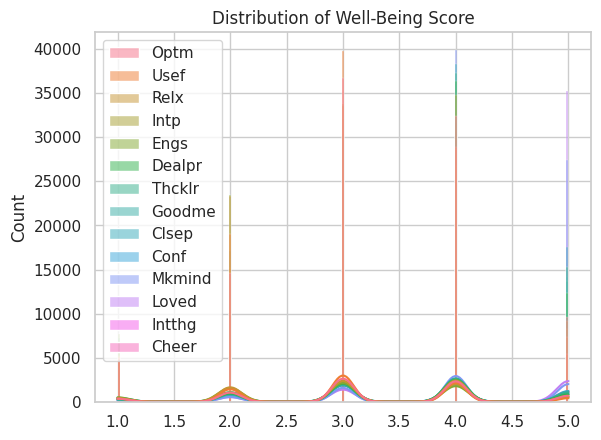

In [18]:

sns.histplot(merged_df[target_variables], kde=True)
plt.title('Distribution of Well-Being Score')
plt.show()


<h2><b>Box Plots for Outlier Detection</b></h2>

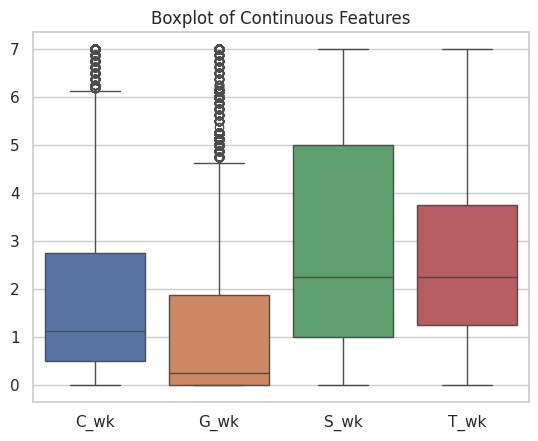

In [19]:
sns.boxplot(merged_df[continuous_features])
plt.title('Boxplot of Continuous Features')
plt.show()


<h3><b>Cap Outliers</b></h3>

In [20]:
import numpy as np
for feat in continuous_features:
    Q1 = merged_df[feat].quantile(0.25)
    Q3 = merged_df[feat].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    merged_df[feat] = np.where(merged_df[feat] > upper_bound, upper_bound, np.where(merged_df[feat] < lower_bound, lower_bound, merged_df[feat]))


<h2><b>Categorical Data Exploration</b></h2>

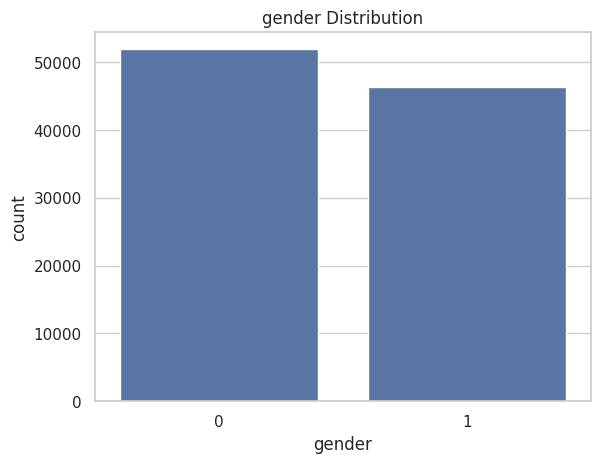

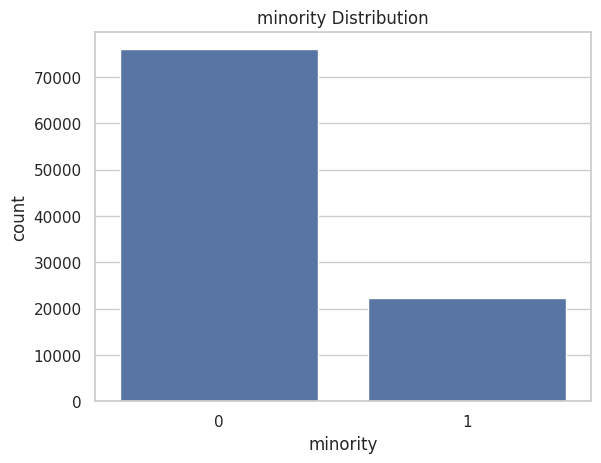

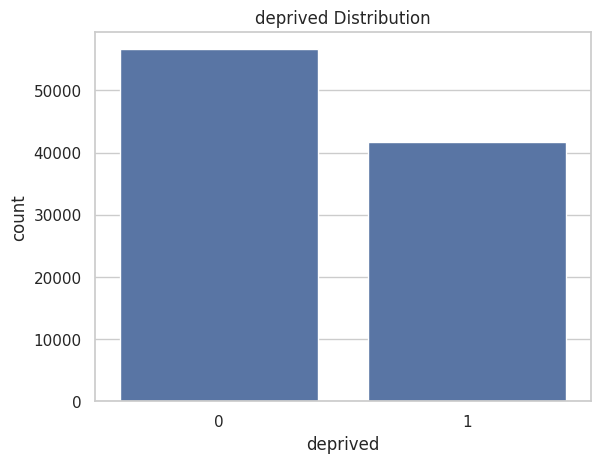

In [21]:
for feat in categorical_features:
    sns.countplot(x=feat, data=merged_df)
    plt.title(f'{feat} Distribution')
    plt.show()


<h3><b>Data Transformation<b><h3>

In [22]:
import numpy as np

# Min-Max normalization for all columns in the DataFrame
for column in merged_df.columns:
    # Check if the column is numeric
    if np.issubdtype(merged_df[column].dtype, np.number):
        min_val = merged_df[column].min()
        max_val = merged_df[column].max()
        
        # Apply Min-Max normalization
        merged_df[column] = (merged_df[column] - min_val) / (max_val - min_val)

In [29]:
merged_df = merged_df.drop(columns='ID')

In [30]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_classif, f_regression, RFE
from sklearn.preprocessing import PolynomialFeatures
from sklearn.decomposition import PCA

# Initialize a dictionary to store feature importance results
feature_importance_results = {}
score_threshold = 0.1  # Set your score threshold here for univariate selection

# Function to check if a variable is categorical or continuous
def is_categorical(variable):
    return len(variable.unique()) < 10  # Adjust threshold for your context

# Iterate over each target variable
for target in target_variables:
    print(f'--- Analysis for Target Variable: {target} ---')

    # Separate features and target
    X = merged_df.drop(columns=target_variables)  # Features
    y = merged_df[target]  # Target variable


    model = RandomForestRegressor(n_estimators=100, random_state=42)
    score_func = f_regression

    # 1. Univariate Feature Selection
    k_best = SelectKBest(score_func=score_func, k='all')
    X_new = k_best.fit_transform(X, y)

    # Get scores and feature names
    scores = k_best.scores_
    features = X.columns
    feature_scores = pd.DataFrame({'Feature': features, 'Score': scores})
    feature_scores = feature_scores.sort_values(by='Score', ascending=False)

    # Filter features based on score threshold
    important_features = feature_scores[feature_scores['Score'] > score_threshold]

    # Store results for univariate selection
    feature_importance_results[target] = {
        'Univariate': important_features
    }

    # 2. Random Forest Feature Importance
    model.fit(X, y)
    importances = model.feature_importances_
    importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
    importance_df = importance_df.sort_values(by='Importance', ascending=False)

    # Filter features based on importance
    important_rf_features = importance_df[importance_df['Importance'] > score_threshold]

    # Store results for random forest
    feature_importance_results[target]['Random Forest'] = important_rf_features

    # 3. Recursive Feature Elimination (RFE)
    rfe = RFE(estimator=model, n_features_to_select=5)  # Adjust number of features as needed
    rfe.fit(X, y)
    selected_features = X.columns[rfe.support_]

    # Store results for RFE
    feature_importance_results[target]['RFE'] = selected_features

    # Print results for each target variable
    print("Important Features Based on Univariate Selection:")
    print(feature_importance_results[target]['Univariate'])

    print("Important Features Based on Random Forest:")
    print(feature_importance_results[target]['Random Forest'])

    print("Selected Features Based on RFE:")
    print(selected_features)
    print()  # Newline for readability

# Combine all important features for all target variables based on scores
all_important_features = set()

for target, results in feature_importance_results.items():
    all_important_features.update(results['Univariate']['Feature'].values)
    all_important_features.update(results['Random Forest']['Feature'].values)
    all_important_features.update(results['RFE'])

# Identify non-important features based on score thresholds
non_important_features = X.columns[~X.columns.isin(all_important_features)]
print("Removed Non-Important Features:")
print(non_important_features)

--- Analysis for Target Variable: Optm ---
Important Features Based on Univariate Selection:
    Feature       Score
0    gender  643.637165
5      S_wk  513.656365
6      T_wk  318.322078
1  minority  150.961383
4      G_wk   96.621931
3      C_wk   36.474961
2  deprived    7.736451
Important Features Based on Random Forest:
  Feature  Importance
6    T_wk    0.280993
3    C_wk    0.243597
5    S_wk    0.219418
4    G_wk    0.160810
Selected Features Based on RFE:
Index(['deprived', 'C_wk', 'G_wk', 'S_wk', 'T_wk'], dtype='object')

--- Analysis for Target Variable: Usef ---
Important Features Based on Univariate Selection:
    Feature        Score
0    gender  2864.412576
5      S_wk  2165.044628
6      T_wk   605.350097
1  minority   178.447418
3      C_wk   173.039212
4      G_wk    35.677968
2  deprived    17.712108
Important Features Based on Random Forest:
  Feature  Importance
6    T_wk    0.264170
3    C_wk    0.236455
5    S_wk    0.201326
4    G_wk    0.175310
Selected Featur

<h3><b>Drop Unimportant Features</b></h3>

In [32]:
merged_df = merged_df.drop(columns='minority')

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

# Split the dataset into features (X) and targets (y)
X = merged_df.drop(columns=target_variables)
y = merged_df[target_variables]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components=6)
X_pca = pca.fit_transform(X_scaled)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

# Hyperparameter tuning using GridSearchCV
ridge_params = {'estimator__alpha': [0.01, 0.1, 1, 10, 100]}
lasso_params = {'estimator__alpha': [0.01, 0.1, 1, 10, 100]}

ridge_grid = GridSearchCV(MultiOutputRegressor(Ridge()), ridge_params, cv=5, scoring='neg_mean_squared_error')
lasso_grid = GridSearchCV(MultiOutputRegressor(Lasso()), lasso_params, cv=5, scoring='neg_mean_squared_error')

ridge_grid.fit(X_train, y_train)
lasso_grid.fit(X_train, y_train)

best_ridge_model = ridge_grid.best_estimator_
best_lasso_model = lasso_grid.best_estimator_

# Fit the linear model on selected features
multi_linear_model = MultiOutputRegressor(LinearRegression())
multi_linear_model.fit(X_train, y_train)

# Predict using the models
y_pred_linear = multi_linear_model.predict(X_test)
y_pred_ridge = best_ridge_model.predict(X_test)
y_pred_lasso = best_lasso_model.predict(X_test)

# Evaluate models
def evaluate_model(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred, multioutput='uniform_average')
    mae = mean_absolute_error(y_true, y_pred, multioutput='uniform_average')
    r2 = r2_score(y_true, y_pred, multioutput='uniform_average')
    return mse, mae, r2

mse_linear, mae_linear, r2_linear = evaluate_model(y_test, y_pred_linear)
mse_ridge, mae_ridge, r2_ridge = evaluate_model(y_test, y_pred_ridge)
mse_lasso, mae_lasso, r2_lasso = evaluate_model(y_test, y_pred_lasso)

# Print evaluation metrics
print(f"Linear Regression - MSE: {mse_linear}, MAE: {mae_linear}, R2: {r2_linear}")
print(f"Ridge Regression - MSE: {mse_ridge}, MAE: {mae_ridge}, R2: {r2_ridge}")
print(f"Lasso Regression - MSE: {mse_lasso}, MAE: {mae_lasso}, R2: {r2_lasso}")




Linear Regression - MSE: 0.06394200231821437, MAE: 0.2056148024317462, R2: 0.048418378334627414
Ridge Regression - MSE: 0.06394186165573747, MAE: 0.20561755240340865, R2: 0.048420202295135724
Lasso Regression - MSE: 0.0643470808691676, MAE: 0.20669000880828162, R2: 0.042306637806266305


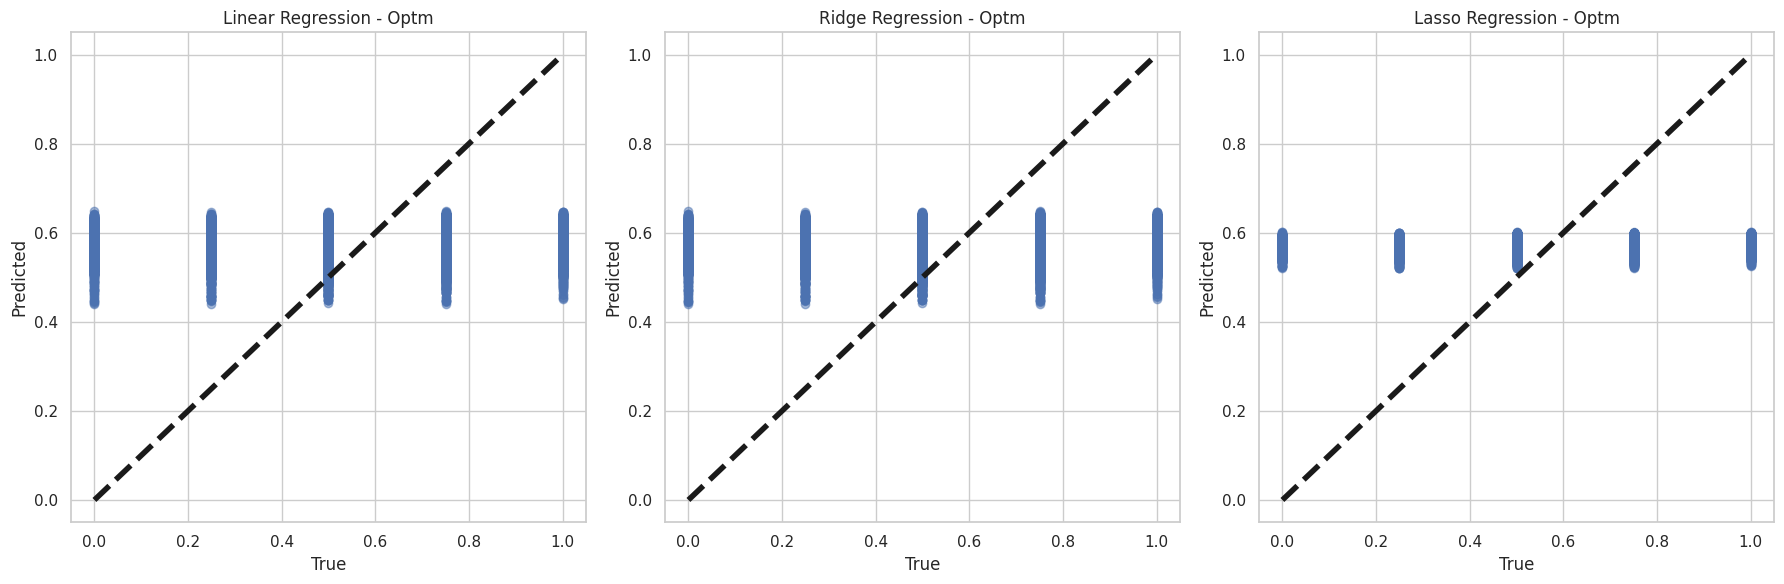

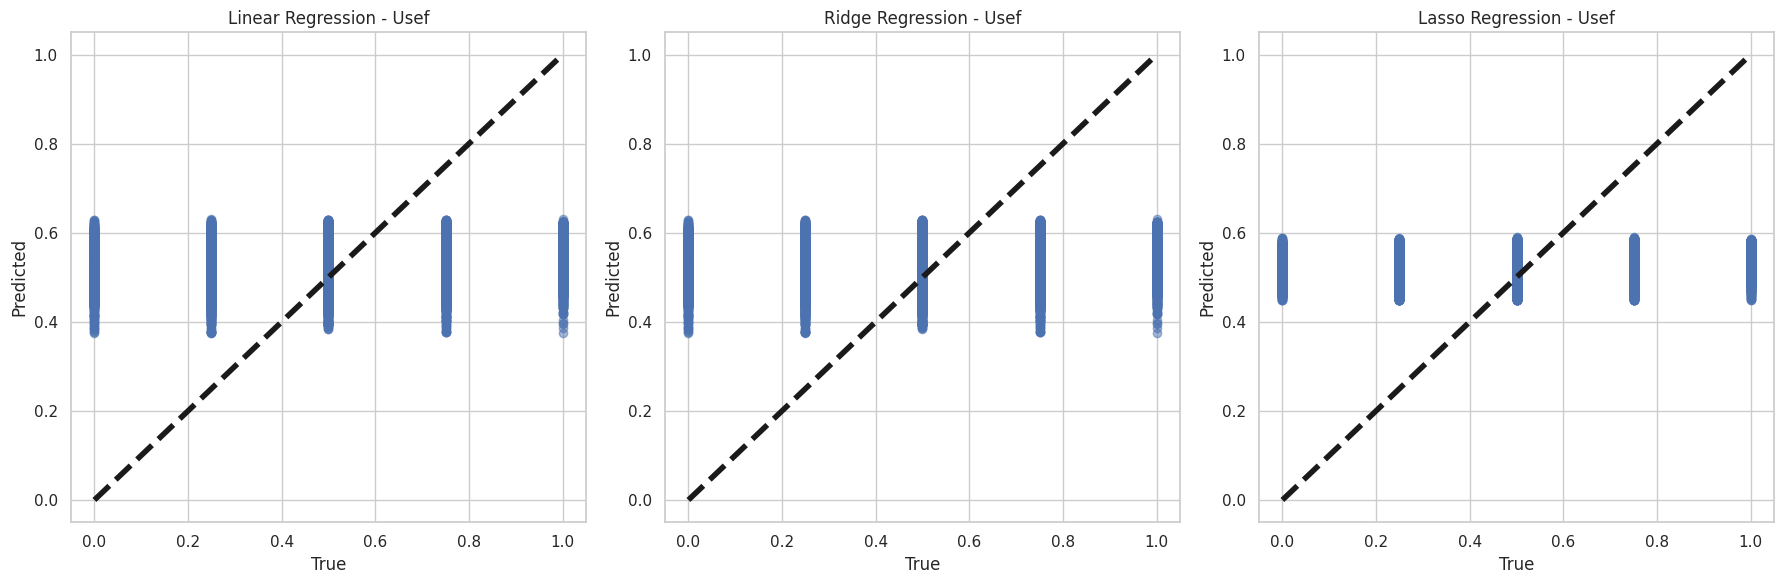

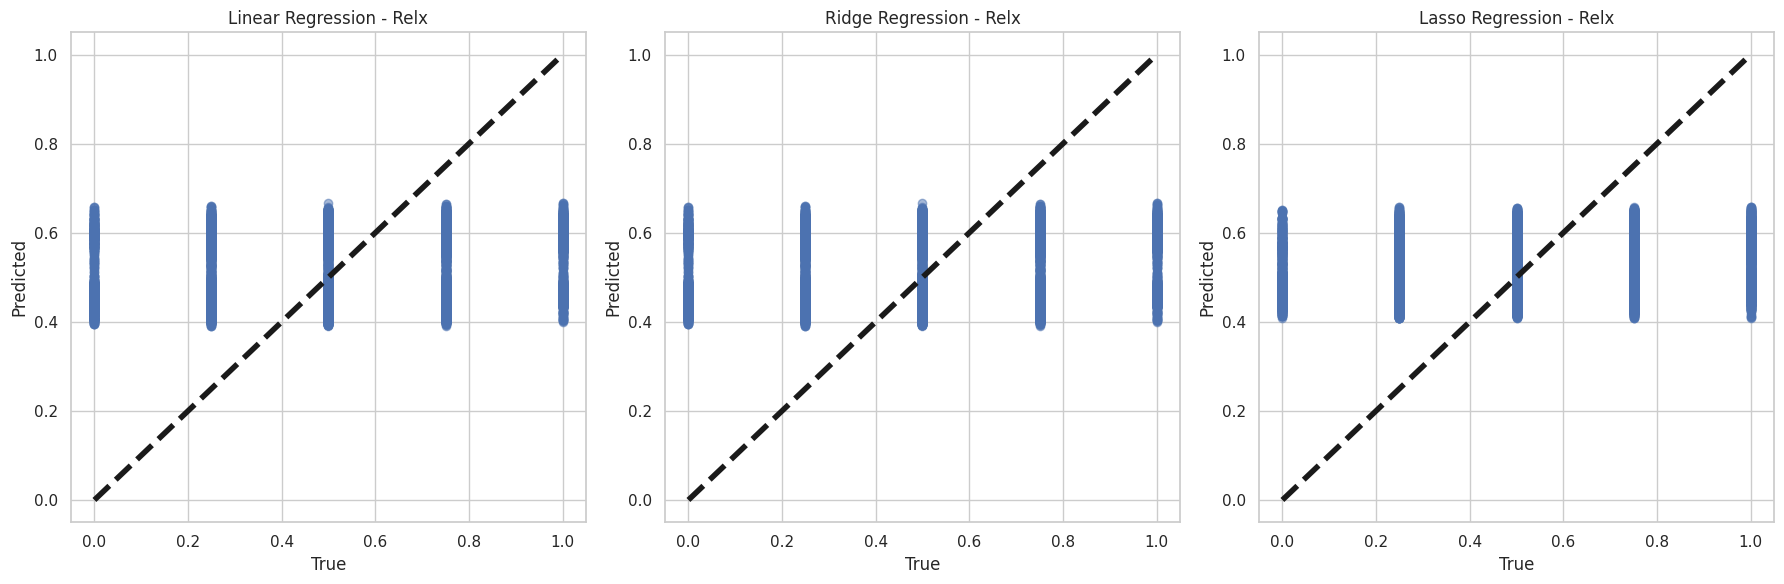

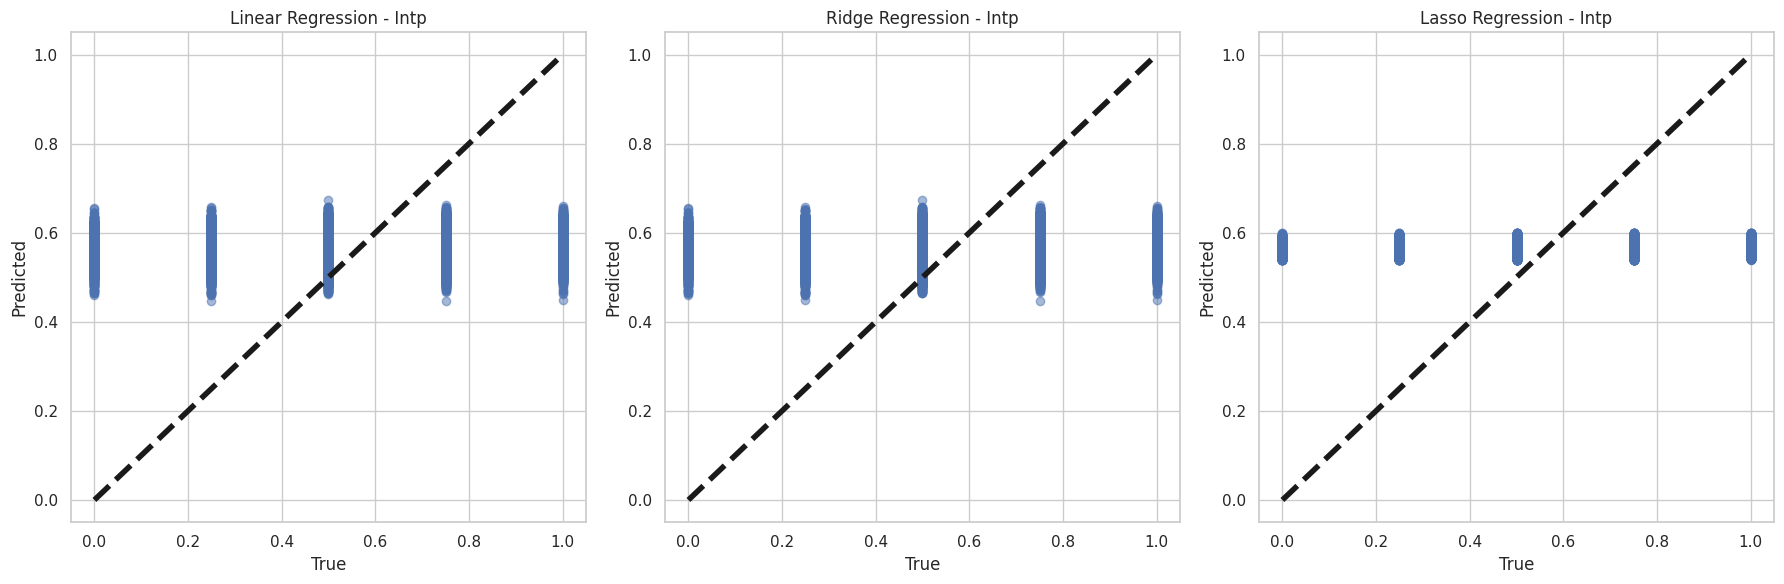

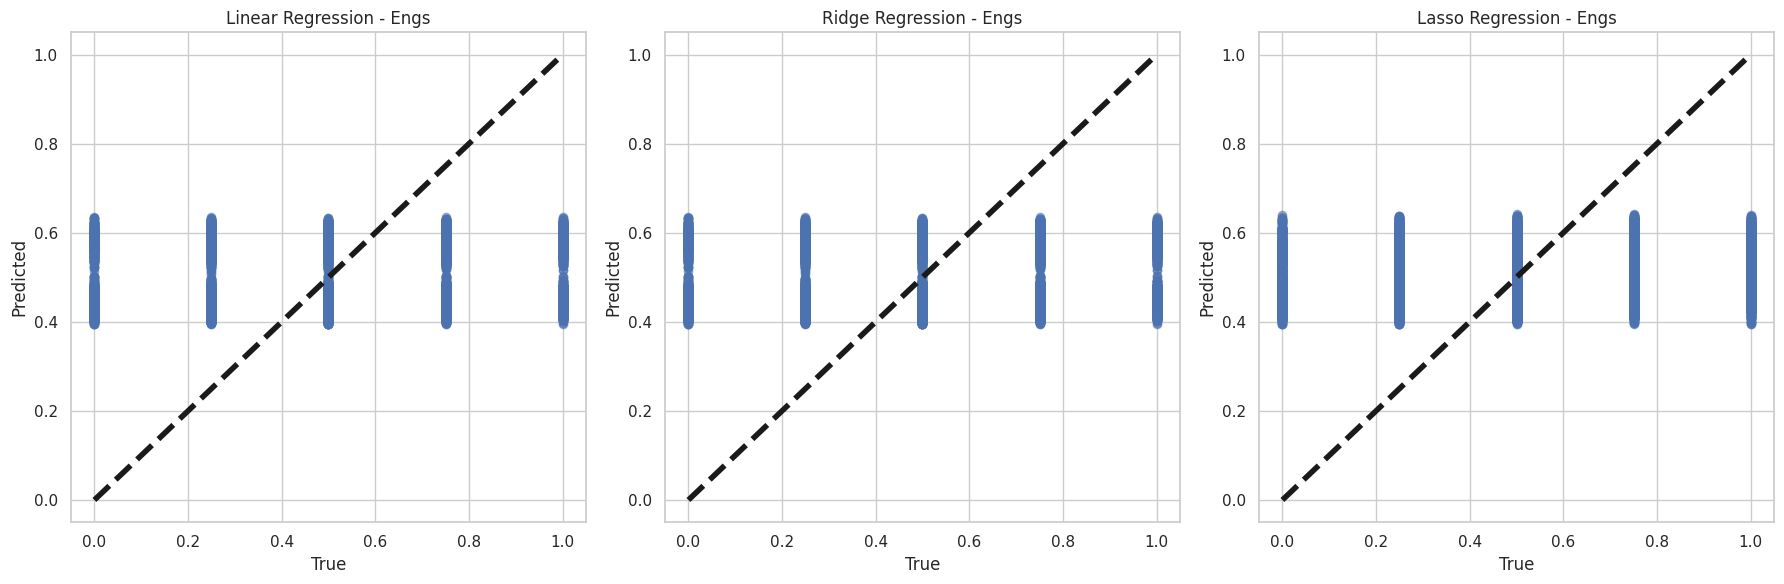

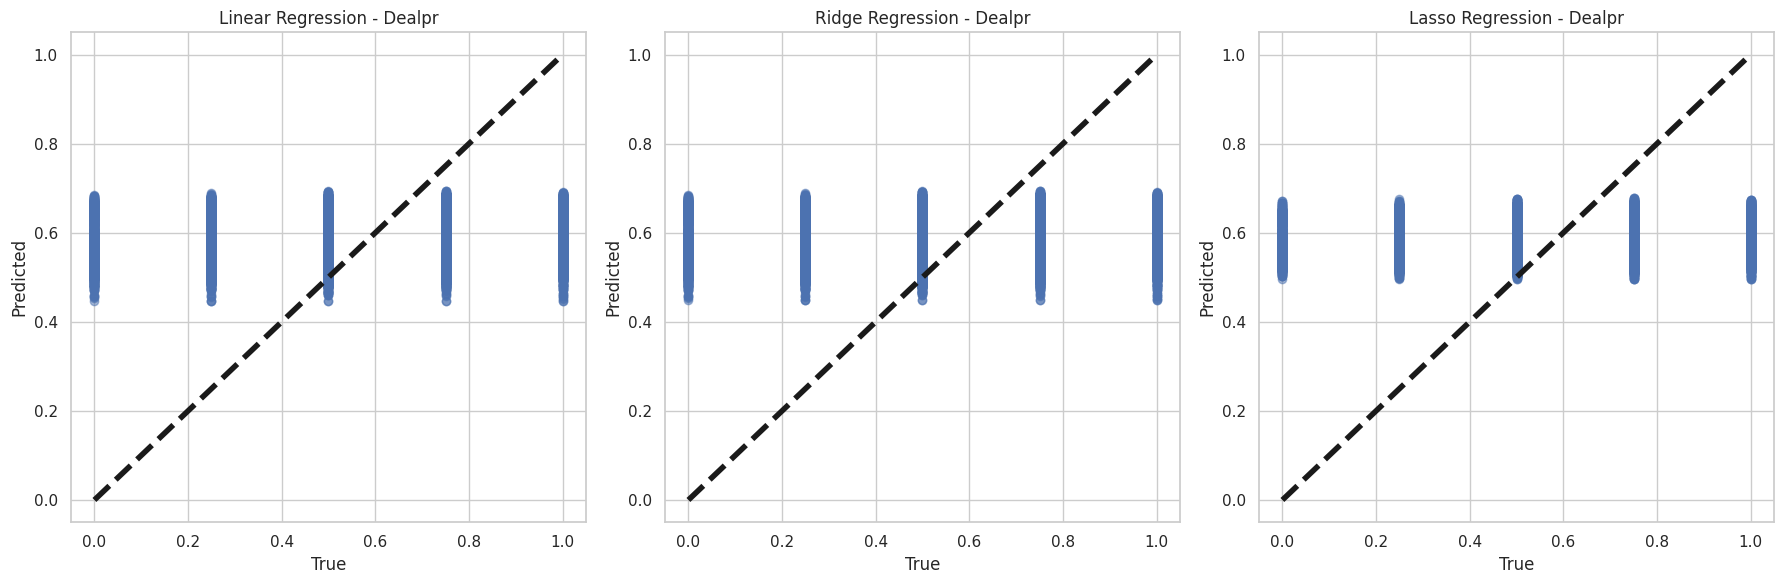

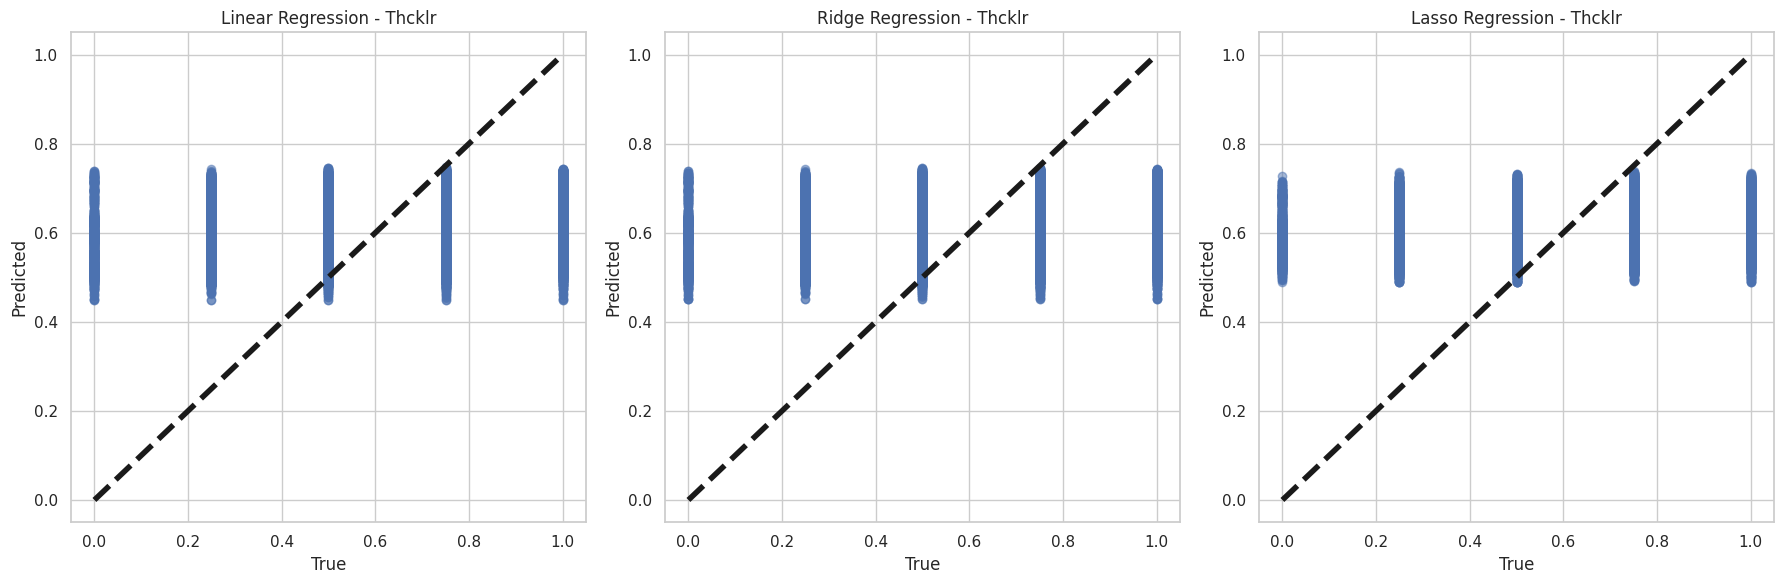

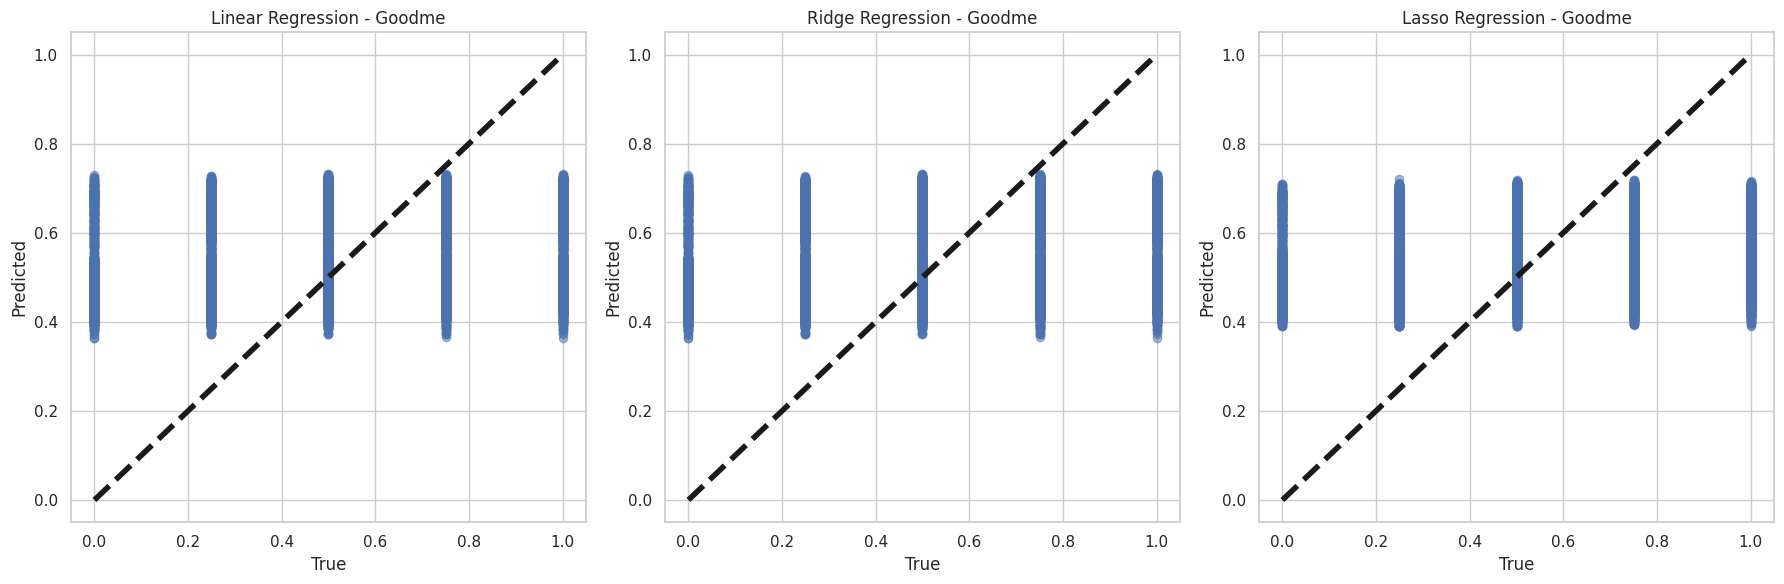

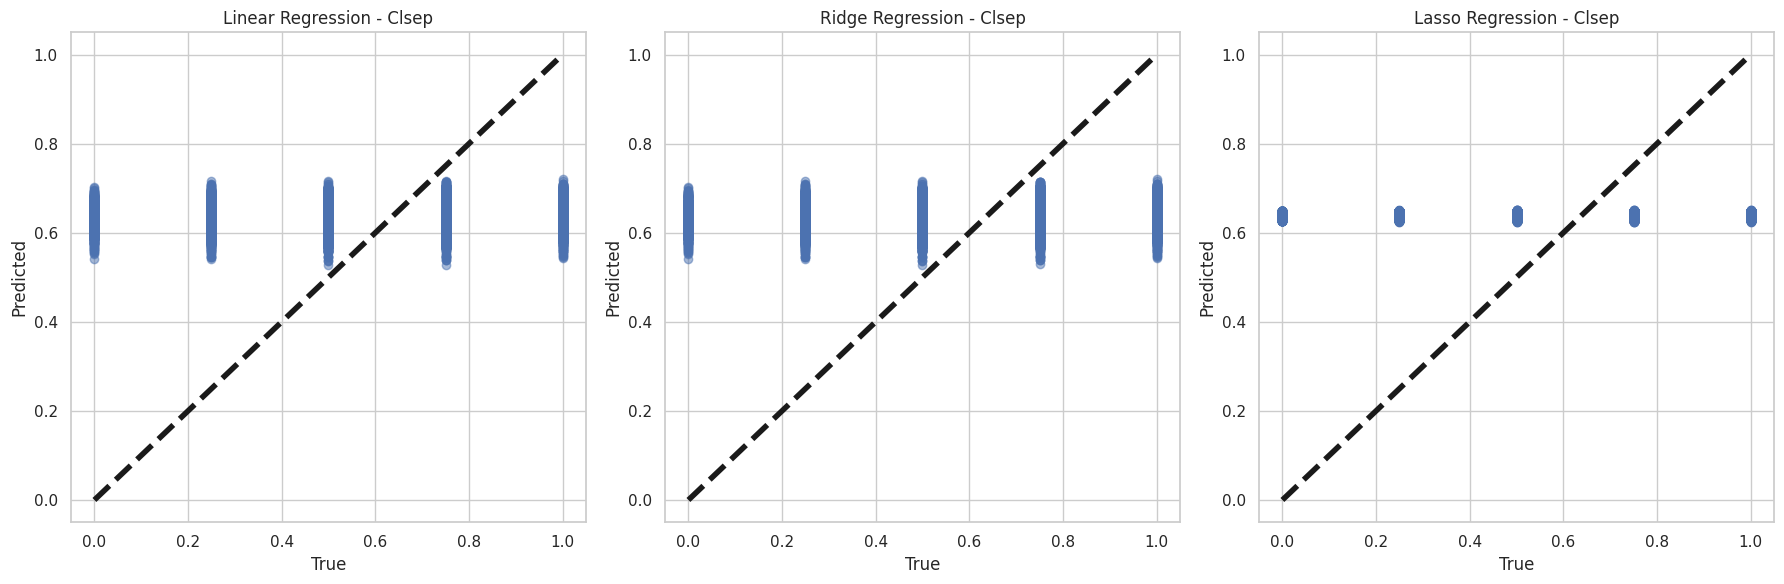

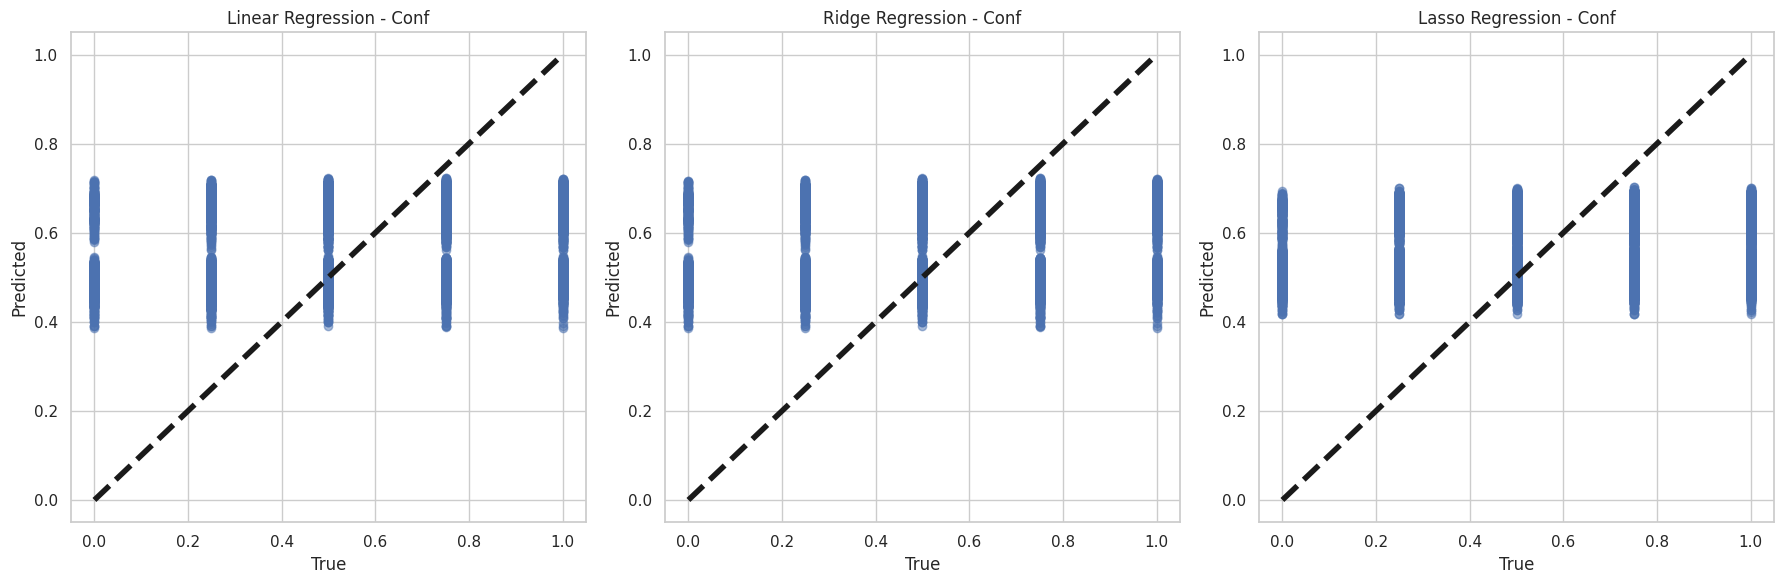

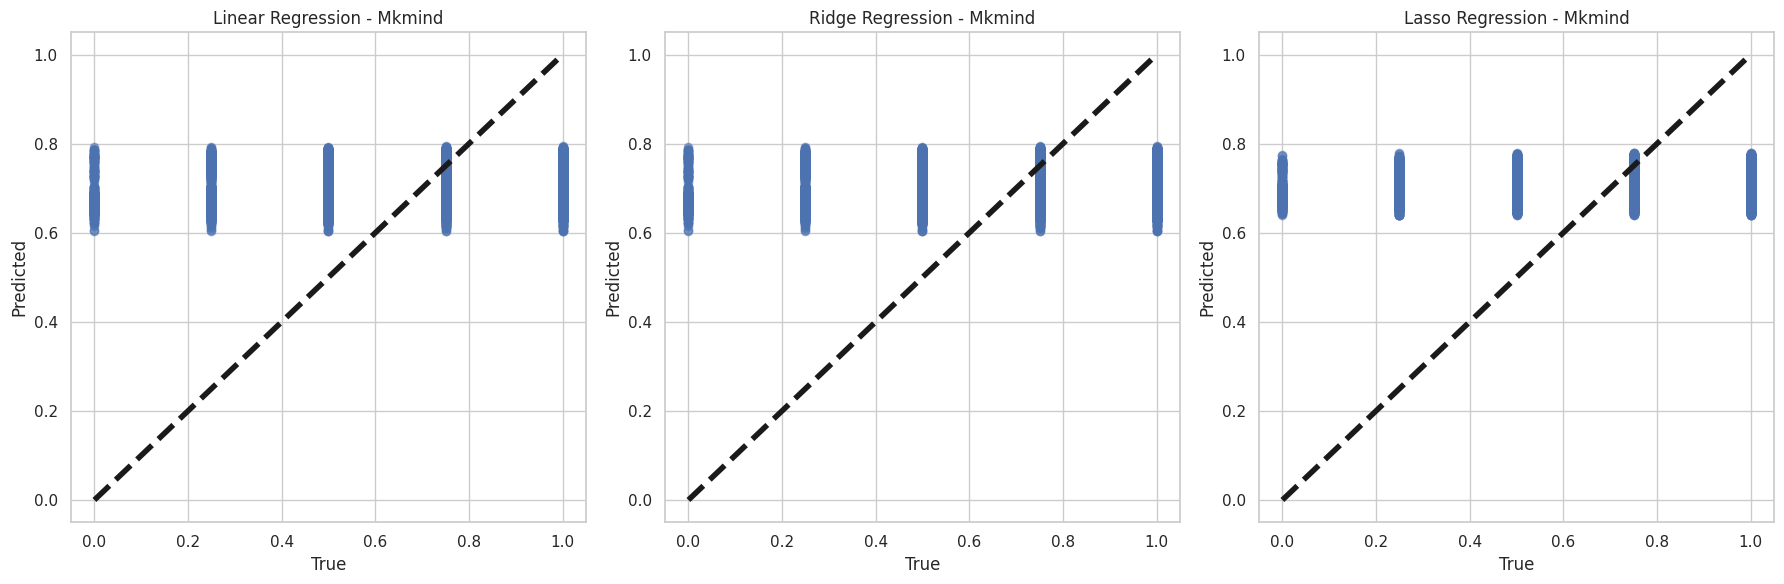

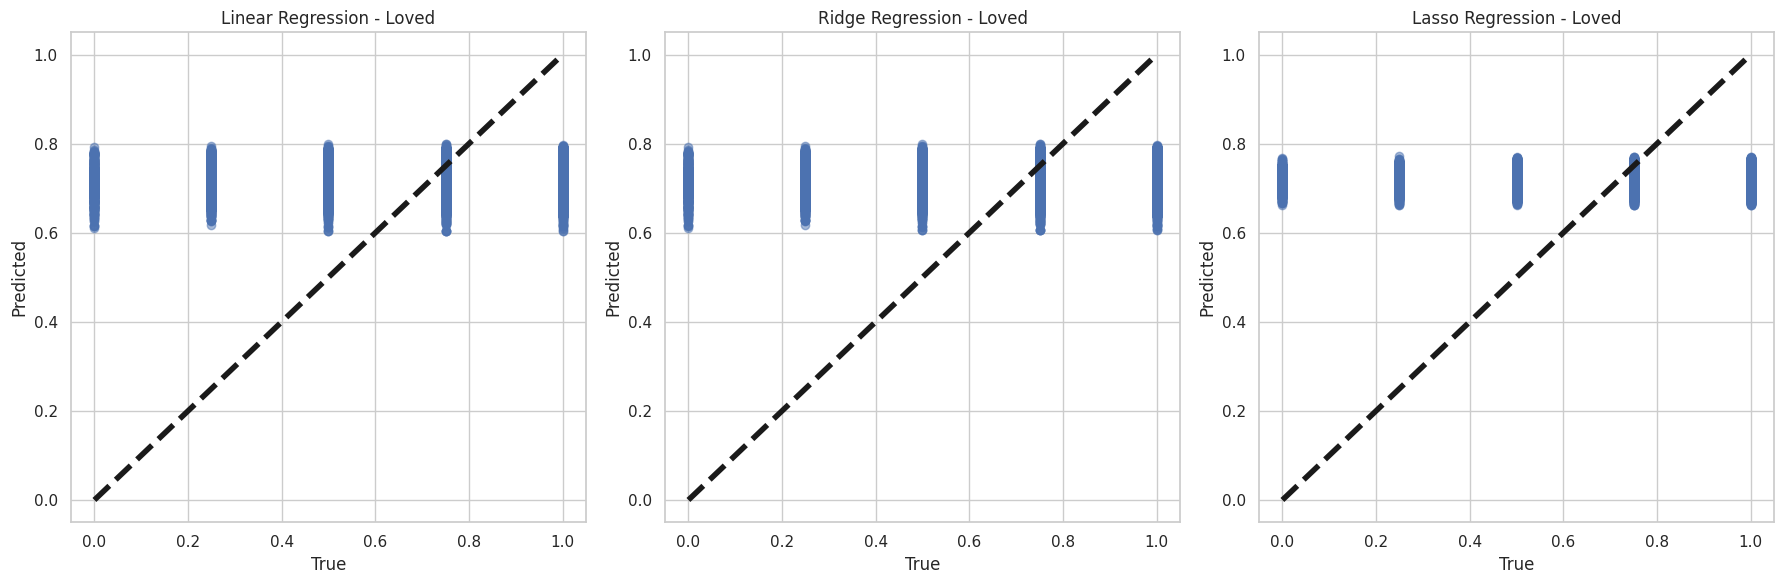

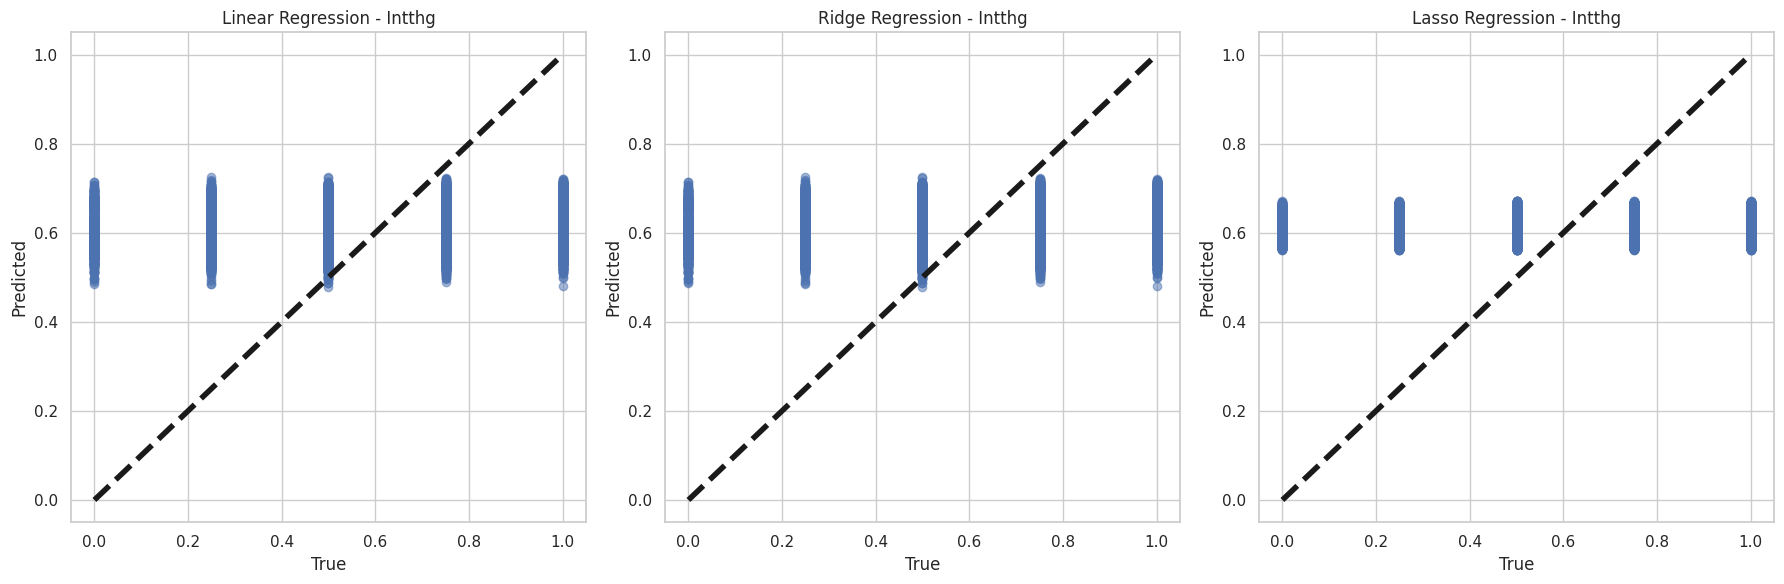

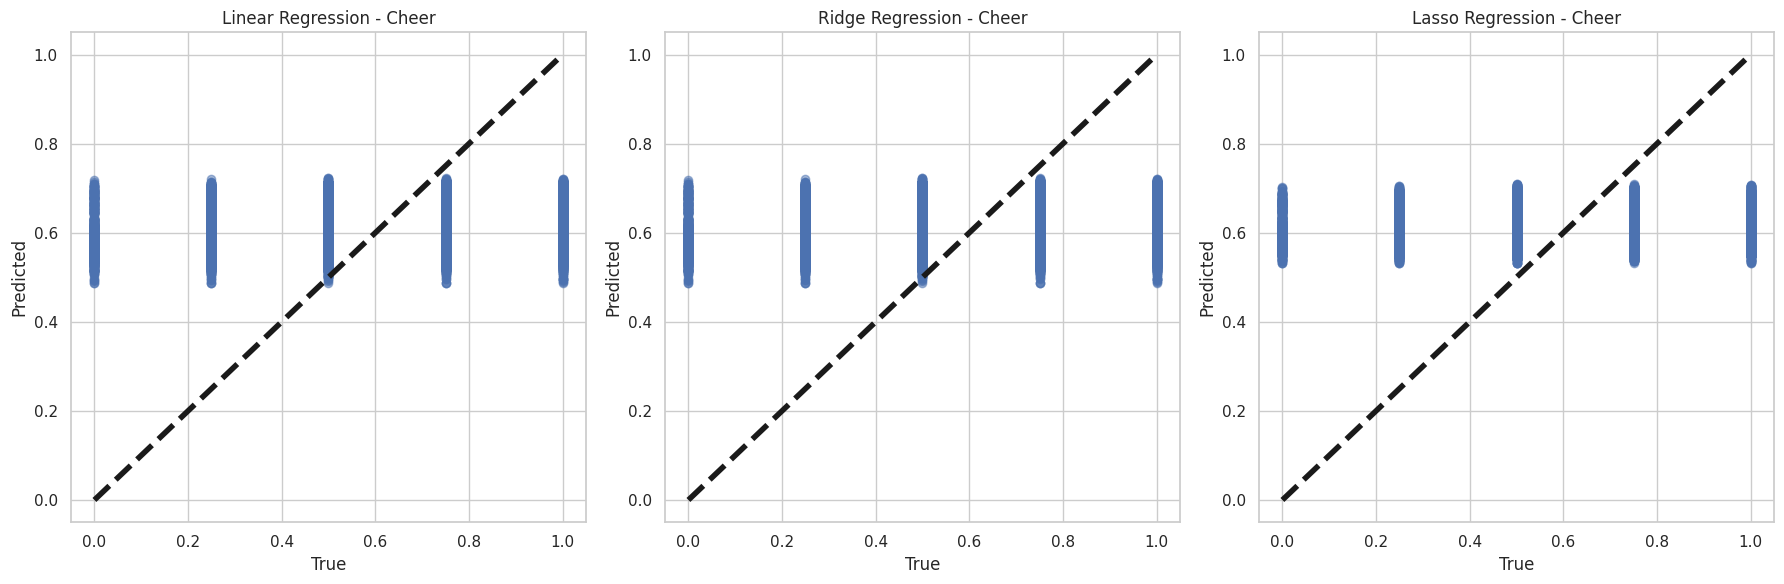

Summary for target variable: Optm
                            OLS Regression Results                            
Dep. Variable:                   Optm   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     236.9
Date:                Wed, 16 Oct 2024   Prob (F-statistic):          3.53e-301
Time:                        15:02:37   Log-Likelihood:                -1692.2
No. Observations:               78622   AIC:                             3398.
Df Residuals:                   78615   BIC:                             3463.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.5

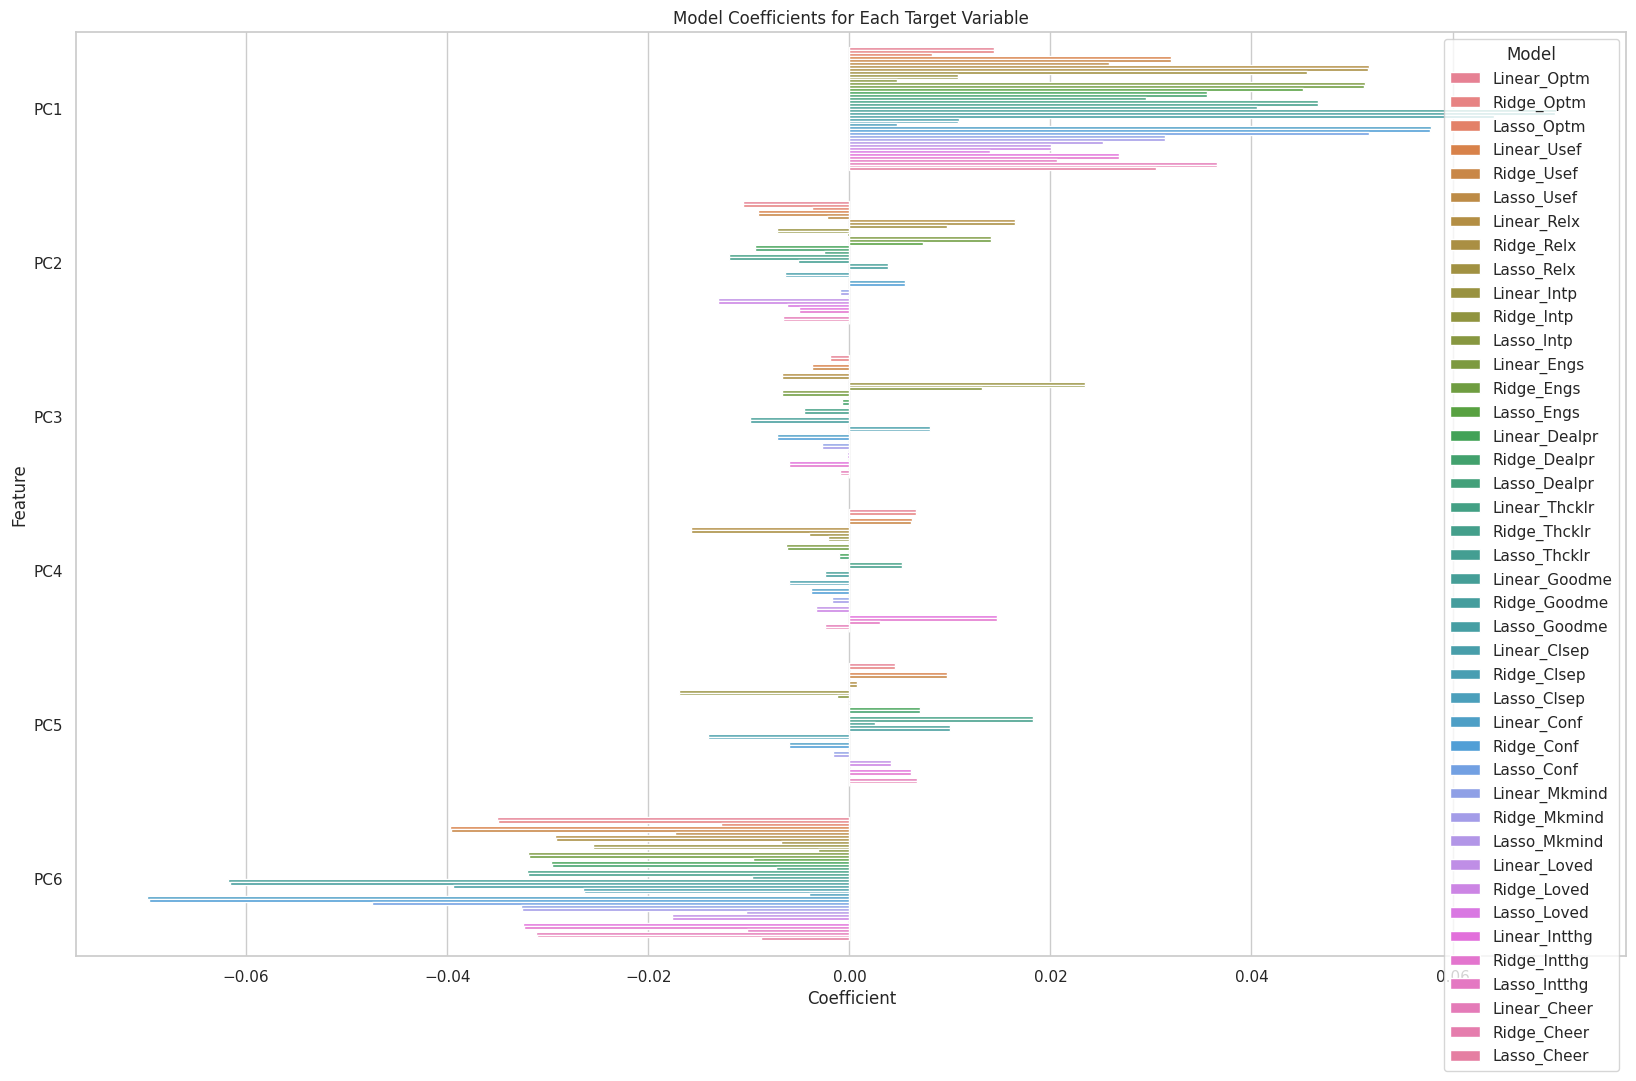

In [39]:
# Visualize results for all target variables
for i, target in enumerate(target_variables):
    plt.figure(figsize=(18, 6))
    plt.subplot(1, 3, 1)
    plt.scatter(y_test.iloc[:, i], y_pred_linear[:, i], alpha=0.5)
    plt.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 'k--', lw=4)
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title(f'Linear Regression - {target}')

    plt.subplot(1, 3, 2)
    plt.scatter(y_test.iloc[:, i], y_pred_ridge[:, i], alpha=0.5)
    plt.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 'k--', lw=4)
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title(f'Ridge Regression - {target}')

    plt.subplot(1, 3, 3)
    plt.scatter(y_test.iloc[:, i], y_pred_lasso[:, i], alpha=0.5)
    plt.plot([y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], [y_test.iloc[:, i].min(), y_test.iloc[:, i].max()], 'k--', lw=4)
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.title(f'Lasso Regression - {target}')

    plt.tight_layout()
    plt.show()

# Model interpretation using statsmodels for Linear Regression for each target
for i, target in enumerate(target_variables):
    X_train_sm = sm.add_constant(X_train)
    linear_model_sm = sm.OLS(y_train.iloc[:, i], X_train_sm).fit()
    print(f"Summary for target variable: {target}")
    print(linear_model_sm.summary())

# Plotting the coefficients for each target variable
coefficients = pd.DataFrame({
    'Feature': [f'PC{i+1}' for i in range(X_train.shape[1])]
})

for i, target in enumerate(target_variables):
    coefficients[f'Linear_{target}'] = multi_linear_model.estimators_[i].coef_
    coefficients[f'Ridge_{target}'] = best_ridge_model.estimators_[i].coef_
    coefficients[f'Lasso_{target}'] = best_lasso_model.estimators_[i].coef_

coefficients_melted = coefficients.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')
plt.figure(figsize=(20, 12))
sns.barplot(x='Coefficient', y='Feature', hue='Model', data=coefficients_melted)
plt.title('Model Coefficients for Each Target Variable')
plt.show()
